In [36]:
print('Built and Trained by Arion Kennedy')

Built and Trained by Arion Kennedy


In [1]:
import pandas as pd

df=pd.read_csv('car_price_prediction.csv')
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [2]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [3]:
X = df[['Prod. year', 'Mileage', 'Fuel type', 'Gear box type', 'Manufacturer', 'Model' ]]
y = df['Price']

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
print(X.columns)

Index(['Prod. year', 'Mileage_1000 km', 'Mileage_10000 km',
       'Mileage_100000 km', 'Mileage_1000000 km', 'Mileage_100006 km',
       'Mileage_10003 km', 'Mileage_100037 km', 'Mileage_100069 km',
       'Mileage_100070 km',
       ...
       'Model_Zafira B', 'Model_i20', 'Model_i3', 'Model_i40', 'Model_iA isti',
       'Model_kona', 'Model_macan', 'Model_macan S', 'Model_tC', 'Model_xD'],
      dtype='object', length=9349)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = model.predict(X_test)

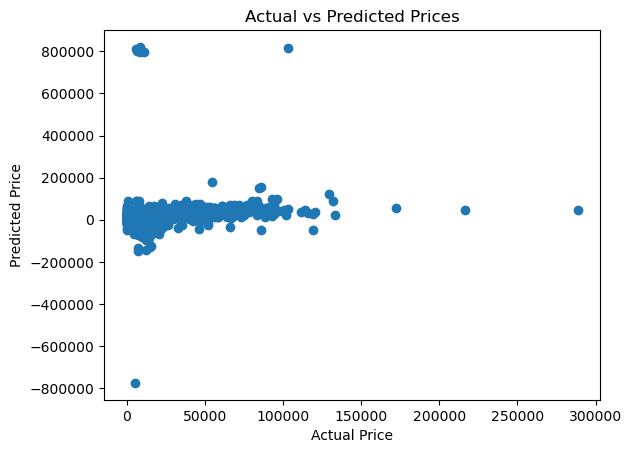

In [9]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [10]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coeff_df)

                     Coefficient
Prod. year          1.394456e+03
Mileage_1000 km     1.089562e+04
Mileage_10000 km    9.829207e+03
Mileage_100000 km   1.311161e+04
Mileage_1000000 km  3.453533e-07
...                          ...
Model_kona          6.617677e+03
Model_macan         0.000000e+00
Model_macan S       0.000000e+00
Model_tC           -1.181832e+04
Model_xD           -3.269412e+03

[9349 rows x 1 columns]


In [11]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1623223673.7393074
R2 Score: -4.209375189762594


In [12]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))

In [13]:
import json

features = list(X.columns)
json.dump(features, open('features.json', 'w'))